In [4]:

#    “Copyright (C) 2024 Mississippi State University.
 
#    This program is free software: you can redistribute it and/or modify
#    it under the terms of the GNU General Public License as published by
#    the Free Software Foundation, either version 3 of the License, or
#    (at your option) any later version.
 
#    This program is distributed in the hope that it will be useful,
#    but WITHOUT ANY WARRANTY; without even the implied warranty of
#    MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
#    GNU General Public License for more details.
 
#    You should have received a copy of the GNU General Public License
#    along with this program.  If not, see <https://www.gnu.org/licenses/>.
 
# To inquire about relicensing, accessing more training data, collaborating with the author, or any general inquiry about the software, please contact Mississippi State University’s Office of Technology Management at otm@msstate.edu, (662) 325-9263.”

#Deoendent Libraries
import numpy as np
import rasterio
import os
from rasterio.windows import Window
import matplotlib.pyplot as plt
from rasterio.mask import mask
from rasterio.transform import xy
import geopandas as gpd
from shapely.geometry import Polygon, mapping
import tkinter as tk
from tkinter import filedialog, messagebox, ttk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from matplotlib.figure import Figure




# file paths to your bands
b_image     = 'C:\\Users\\Say70\\OneDrive - Mississippi State University\\Desktop\\UGA talk\\6_10_2020\\raw\\6_10_2020_B.tif'
g_image     = 'C:\\Users\\Say70\\OneDrive - Mississippi State University\\Desktop\\UGA talk\\6_10_2020\\raw\\6_10_2020_g.tif'
r_image     = 'C:\\Users\\Say70\\OneDrive - Mississippi State University\\Desktop\\UGA talk\\6_10_2020\\raw\\6_10_2020_r.tif'
re_image    = 'C:\\Users\\Say70\\OneDrive - Mississippi State University\\Desktop\\UGA talk\\6_10_2020\\raw\\6_10_2020_re.tif'
nir_image   = 'C:\\Users\\Say70\\OneDrive - Mississippi State University\\Desktop\\UGA talk\\6_10_2020\\raw\\6_10_2020_nir.tif'


# open one of the bands to obtain CRS information
with rasterio.open(b_image) as src_b:
    band_crs = src_b.crs

# open each band using rasterio
with rasterio.open(b_image) as src_b, \
     rasterio.open(g_image) as src_g, \
     rasterio.open(r_image) as src_r, \
     rasterio.open(re_image) as src_re, \
     rasterio.open(nir_image) as src_nir:

    # read the band data
    b_band   = src_b.read(1)
    g_band   = src_g.read(1)
    r_band   = src_r.read(1)
    re_band  = src_re.read(1)
    nir_band = src_nir.read(1)
    
    # Print the CRS information for each band
    print(f"CRS for band B: {src_b.crs}")
    print(f"CRS for band G: {src_g.crs}")
    print(f"CRS for band R: {src_r.crs}")
    print(f"CRS for band RE: {src_re.crs}")
    print(f"CRS for band NIR: {src_nir.crs}")
    
    #print shape for all band
    print(b_band.shape)
    print(g_band.shape)
    print(r_band.shape)
    print(re_band.shape)
    print(nir_band.shape)

# stack the bands into a single 5-band image
stack_image = np.stack((b_band, g_band, r_band, re_band, nir_band), axis=-1)

# Output directory path
output_dir = 'C:/Users/Say70/OneDrive - Mississippi State University/Desktop/UGA talk/6_10_2020/stack/'

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# output file path
output_path = os.path.join(output_dir, '6_10_2020_stack.tif')


# Create a new raster file with the same dimensions as one of the input bands
with rasterio.open(output_path, 'w', driver='GTiff', width=src_r.width, height=src_r.height, count=5, dtype=stack_image.dtype, crs=src_b.crs, transform=src_b.transform) as dst:
    # Write each band separately
    for i in range(5):
        dst.write(stack_image[:, :, i], i + 1)

        
print(f'Stacked image saved to {output_path}')

#Sanity Check for stacked image shape and size

print(stack_image.shape)

# Check the CRS of the stacked image
stacked_image_crs = dst.crs

# Print the CRS information
print("CRS of the stacked image:", stacked_image_crs)

 

CRS for band B: EPSG:3857
CRS for band G: EPSG:3857
CRS for band R: EPSG:3857
CRS for band RE: EPSG:3857
CRS for band NIR: EPSG:3857
(4008, 10113)
(4008, 10113)
(4008, 10113)
(4008, 10113)
(4008, 10113)
Stacked image saved to C:/Users/Say70/OneDrive - Mississippi State University/Desktop/UGA talk/6_10_2020/stack/6_10_2020_stack.tif
(4008, 10113, 5)
CRS of the stacked image: EPSG:3857


CRS: EPSG:3857
Width: 10113
Height: 4008
Band count: 5


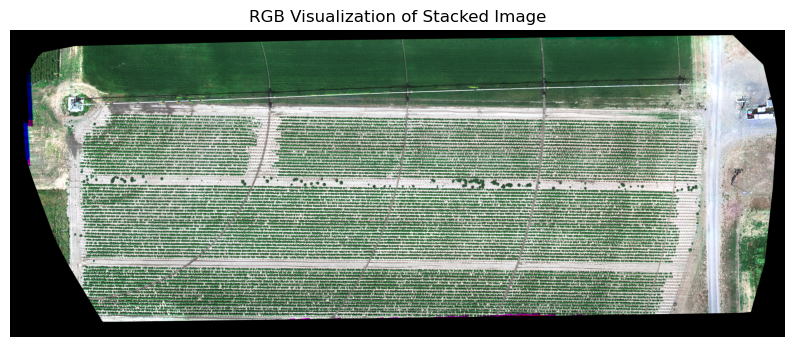

In [5]:
# INPUT STACKED IMAGE

stack_path = r"C:\Users\Say70\OneDrive - Mississippi State University\Desktop\UGA talk\6_10_2020\stack\6_10_2020_stack.tif"


# FUNCTION: STRETCH IMAGE FOR DISPLAY

def percentile_stretch(img, pmin=2, pmax=98):
    """
    Stretch image band-wise for better visualization.
    img should be (rows, cols, bands)
    """
    img = img.astype(np.float32)
    out = np.zeros_like(img, dtype=np.float32)

    for i in range(img.shape[2]):
        band = img[:, :, i]
        low = np.percentile(band[np.isfinite(band)], pmin)
        high = np.percentile(band[np.isfinite(band)], pmax)

        if high > low:
            out[:, :, i] = np.clip((band - low) / (high - low), 0, 1)
        else:
            out[:, :, i] = 0

    return out


# READ STACKED IMAGE

with rasterio.open(stack_path) as src:
    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Band count:", src.count)

    # Read RGB bands
    # Your stack order is: B, G, R, RE, NIR
    # So RGB = bands 3, 2, 1
    r = src.read(3)
    g = src.read(2)
    b = src.read(1)

# Stack into RGB image
rgb = np.dstack((r, g, b))

# Stretch for display
rgb_display = percentile_stretch(rgb)

# VISUALIZATION OPTION 1: LIKE plotRGB(EX1, r=1, g=2, b=3)

plt.figure(figsize=(10, 10))
plt.imshow(rgb_display)
plt.title("RGB Visualization of Stacked Image")
plt.axis("off")
plt.show()

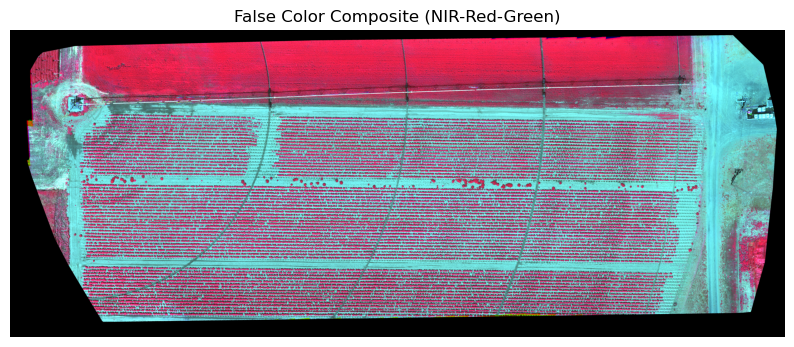

In [6]:
#vegetation-style false color composite like NIR-Red-Green

with rasterio.open(stack_path) as src:
    nir = src.read(5)
    r = src.read(3)
    g = src.read(2)

false_color = np.dstack((nir, r, g))
false_color_display = percentile_stretch(false_color)

plt.figure(figsize=(10, 10))
plt.imshow(false_color_display)
plt.title("False Color Composite (NIR-Red-Green)")
plt.axis("off")
plt.show()

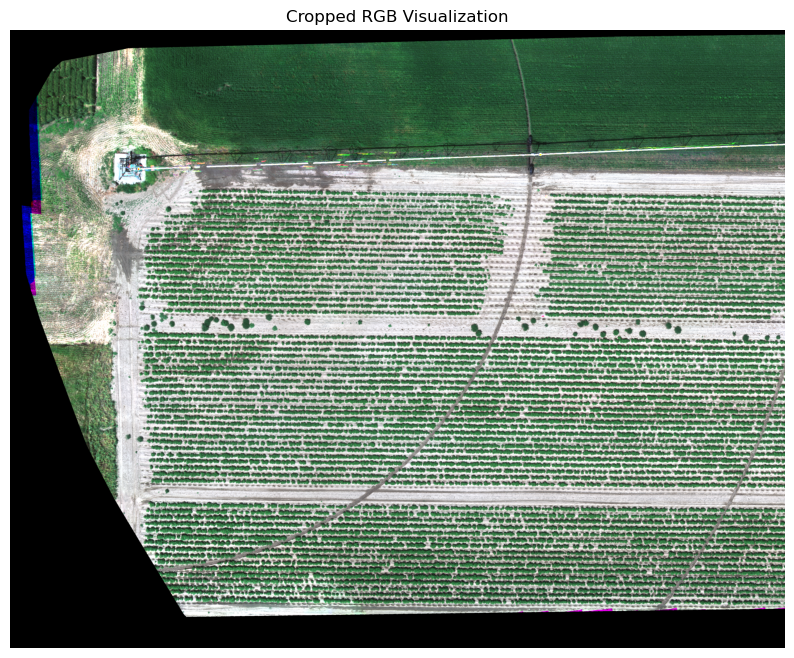

In [7]:
stack_path = r"C:\Users\Say70\OneDrive - Mississippi State University\Desktop\UGA talk\6_10_2020\stack\6_10_2020_stack.tif"

def percentile_stretch(img, pmin=2, pmax=98):
    img = img.astype(np.float32)
    out = np.zeros_like(img, dtype=np.float32)

    for i in range(img.shape[2]):
        band = img[:, :, i]
        low = np.percentile(band[np.isfinite(band)], pmin)
        high = np.percentile(band[np.isfinite(band)], pmax)

        if high > low:
            out[:, :, i] = np.clip((band - low) / (high - low), 0, 1)

    return out

with rasterio.open(stack_path) as src:
    # Example crop window: adjust these values
    row_start, row_end = 100, 5000
    col_start, col_end = 100, 5000

    window = rasterio.windows.Window(
        col_off=col_start,
        row_off=row_start,
        width=col_end - col_start,
        height=row_end - row_start
    )

    b = src.read(1, window=window)
    g = src.read(2, window=window)
    r = src.read(3, window=window)

rgb_crop = np.dstack((r, g, b))
rgb_crop_display = percentile_stretch(rgb_crop)

plt.figure(figsize=(10, 10))
plt.imshow(rgb_crop_display)
plt.title("Cropped RGB Visualization")
plt.axis("off")
plt.show()

In [8]:

class RasterAOIGUI:
    def __init__(self, root):
        self.root = root
        self.root.title("Stacked Raster AOI Selector and Cropper")
        self.root.geometry("1300x850")

        # Raster info
        self.raster_path = None
        self.raster_dir = None
        self.src = None
        self.data = None
        self.transform = None
        self.crs = None
        self.width = None
        self.height = None
        self.count = None

        # AOI info
        self.clicked_points_pixel = []
        self.clicked_points_geo = []
        self.required_points = 4
        self.polygon_geom = None

        # Plot objects
        self.fig = Figure(figsize=(8, 7), dpi=100)
        self.ax = self.fig.add_subplot(111)
        self.canvas = None
        self.scatter_plot = None
        self.line_plot = None

        # UI vars
        self.band_r = tk.IntVar(value=3)
        self.band_g = tk.IntVar(value=2)
        self.band_b = tk.IntVar(value=1)
        self.num_points_var = tk.IntVar(value=4)
        self.stretch_min_var = tk.DoubleVar(value=2)
        self.stretch_max_var = tk.DoubleVar(value=98)

        self._build_gui()

    def _build_gui(self):
        control_frame = tk.Frame(self.root, padx=10, pady=10)
        control_frame.pack(side=tk.LEFT, fill=tk.Y)

        plot_frame = tk.Frame(self.root)
        plot_frame.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True)

        # =========================
        # Controls
        # =========================
        tk.Label(control_frame, text="Raster AOI GUI", font=("Arial", 14, "bold")).pack(pady=5)

        tk.Button(control_frame, text="Load Stacked Raster", width=25, command=self.load_raster).pack(pady=5)

        tk.Label(control_frame, text="Display Bands").pack(pady=(15, 5))

        tk.Label(control_frame, text="Red Band").pack()
        self.combo_r = ttk.Combobox(control_frame, textvariable=self.band_r, width=10, state="readonly")
        self.combo_r.pack(pady=2)

        tk.Label(control_frame, text="Green Band").pack()
        self.combo_g = ttk.Combobox(control_frame, textvariable=self.band_g, width=10, state="readonly")
        self.combo_g.pack(pady=2)

        tk.Label(control_frame, text="Blue Band").pack()
        self.combo_b = ttk.Combobox(control_frame, textvariable=self.band_b, width=10, state="readonly")
        self.combo_b.pack(pady=2)

        tk.Label(control_frame, text="Stretch Min Percentile").pack(pady=(15, 2))
        tk.Entry(control_frame, textvariable=self.stretch_min_var, width=12).pack()

        tk.Label(control_frame, text="Stretch Max Percentile").pack(pady=(10, 2))
        tk.Entry(control_frame, textvariable=self.stretch_max_var, width=12).pack()

        tk.Button(control_frame, text="Show Image", width=25, command=self.display_rgb).pack(pady=10)

        tk.Label(control_frame, text="Number of Polygon Points").pack(pady=(15, 2))
        tk.Entry(control_frame, textvariable=self.num_points_var, width=12).pack()

        tk.Button(control_frame, text="Start Point Selection", width=25, command=self.start_point_selection).pack(pady=10)
        tk.Button(control_frame, text="Reset Points", width=25, command=self.reset_points).pack(pady=5)
        tk.Button(control_frame, text="Save Shapefile + Crop Raster", width=25, command=self.save_outputs).pack(pady=10)

        self.info_label = tk.Label(control_frame, text="Load a raster first.", justify="left", wraplength=250, fg="blue")
        self.info_label.pack(pady=20)

        # =========================
        # Matplotlib Canvas
        # =========================
        self.canvas = FigureCanvasTkAgg(self.fig, master=plot_frame)
        self.canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
        self.canvas.mpl_connect("button_press_event", self.on_click)

    def load_raster(self):
        raster_path = filedialog.askopenfilename(
            title="Select stacked raster",
            filetypes=[("GeoTIFF files", "*.tif *.tiff"), ("All files", "*.*")]
        )
        if not raster_path:
            return

        try:
            if self.src is not None:
                self.src.close()

            self.raster_path = raster_path
            self.raster_dir = os.path.dirname(raster_path)
            self.src = rasterio.open(raster_path)
            self.transform = self.src.transform
            self.crs = self.src.crs
            self.width = self.src.width
            self.height = self.src.height
            self.count = self.src.count

            self.data = self.src.read()  # shape: (bands, rows, cols)

            band_list = list(range(1, self.count + 1))
            self.combo_r["values"] = band_list
            self.combo_g["values"] = band_list
            self.combo_b["values"] = band_list

            # Default if at least 3 bands exist
            if self.count >= 3:
                self.band_r.set(min(3, self.count))
                self.band_g.set(min(2, self.count))
                self.band_b.set(1)

            self.info_label.config(
                text=f"Loaded raster:\n{os.path.basename(self.raster_path)}\n"
                     f"Size: {self.width} x {self.height}\n"
                     f"Bands: {self.count}\nCRS: {self.crs}"
            )

            self.display_rgb()

        except Exception as e:
            messagebox.showerror("Error", f"Failed to load raster:\n{e}")

    def percentile_stretch(self, img, pmin=2, pmax=98):
        img = img.astype(np.float32)
        out = np.zeros_like(img, dtype=np.float32)

        for i in range(img.shape[2]):
            band = img[:, :, i]
            valid = np.isfinite(band)
            if np.any(valid):
                low = np.percentile(band[valid], pmin)
                high = np.percentile(band[valid], pmax)

                if high > low:
                    out[:, :, i] = np.clip((band - low) / (high - low), 0, 1)
                else:
                    out[:, :, i] = 0
            else:
                out[:, :, i] = 0

        return out

    def display_rgb(self):
        if self.data is None:
            messagebox.showwarning("Warning", "Load a raster first.")
            return

        try:
            r_idx = self.band_r.get() - 1
            g_idx = self.band_g.get() - 1
            b_idx = self.band_b.get() - 1

            if min(r_idx, g_idx, b_idx) < 0 or max(r_idx, g_idx, b_idx) >= self.count:
                messagebox.showerror("Error", "Selected band is out of range.")
                return

            rgb = np.dstack((
                self.data[r_idx],
                self.data[g_idx],
                self.data[b_idx]
            ))

            rgb_disp = self.percentile_stretch(
                rgb,
                pmin=self.stretch_min_var.get(),
                pmax=self.stretch_max_var.get()
            )

            self.ax.clear()
            self.ax.imshow(rgb_disp, origin="upper")
            self.ax.set_title(
                f"RGB Display (R={self.band_r.get()}, G={self.band_g.get()}, B={self.band_b.get()})\n"
                f"Click points to define AOI polygon"
            )
            self.ax.set_xlabel("Column")
            self.ax.set_ylabel("Row")

            # redraw existing points if any
            if len(self.clicked_points_pixel) > 0:
                xs = [p[0] for p in self.clicked_points_pixel]
                ys = [p[1] for p in self.clicked_points_pixel]
                self.ax.plot(xs, ys, "ro-", markersize=5)

                if self.polygon_geom is not None and len(self.clicked_points_pixel) >= 3:
                    xs_closed = xs + [xs[0]]
                    ys_closed = ys + [ys[0]]
                    self.ax.plot(xs_closed, ys_closed, "y-", linewidth=2)

            self.canvas.draw()

        except Exception as e:
            messagebox.showerror("Error", f"Failed to display image:\n{e}")

    def start_point_selection(self):
        if self.data is None:
            messagebox.showwarning("Warning", "Load a raster first.")
            return

        self.required_points = self.num_points_var.get()
        if self.required_points < 3:
            messagebox.showwarning("Warning", "Polygon needs at least 3 points.")
            return

        self.reset_points()
        self.info_label.config(
            text=f"Point selection started.\nClick {self.required_points} points on the image."
        )

    def reset_points(self):
        self.clicked_points_pixel = []
        self.clicked_points_geo = []
        self.polygon_geom = None
        self.display_rgb()

    def on_click(self, event):
        if self.data is None:
            return

        if event.inaxes != self.ax:
            return

        if event.xdata is None or event.ydata is None:
            return

        if len(self.clicked_points_pixel) >= self.required_points:
            return

        col = float(event.xdata)
        row = float(event.ydata)

        if col < 0 or row < 0 or col >= self.width or row >= self.height:
            return

        self.clicked_points_pixel.append((col, row))

        # Convert pixel row/col to geospatial coordinate
        x_geo, y_geo = xy(self.transform, int(row), int(col), offset='center')
        self.clicked_points_geo.append((x_geo, y_geo))

        # Update plot
        self.display_rgb()

        if len(self.clicked_points_pixel) == self.required_points:
            self.polygon_geom = Polygon(self.clicked_points_geo)

            # draw closed polygon
            xs = [p[0] for p in self.clicked_points_pixel] + [self.clicked_points_pixel[0][0]]
            ys = [p[1] for p in self.clicked_points_pixel] + [self.clicked_points_pixel[0][1]]
            self.ax.plot(xs, ys, "y-", linewidth=2)
            self.canvas.draw()

            self.info_label.config(
                text=f"Polygon completed with {self.required_points} points.\n"
                     f"You can now save shapefile and crop raster."
            )

    def save_outputs(self):
        if self.polygon_geom is None:
            messagebox.showwarning("Warning", "Please create a polygon first.")
            return

        try:
            base_name = os.path.splitext(os.path.basename(self.raster_path))[0]

            shp_path = os.path.join(self.raster_dir, f"{base_name}_AOI.shp")
            crop_path = os.path.join(self.raster_dir, f"{base_name}_AOI_crop.tif")

            # Save shapefile
            gdf = gpd.GeoDataFrame(
                {"id": [1], "geometry": [self.polygon_geom]},
                crs=self.crs
            )
            gdf.to_file(shp_path)

            # Crop raster
            with rasterio.open(self.raster_path) as src:
                out_image, out_transform = mask(src, [mapping(self.polygon_geom)], crop=True)
                out_meta = src.meta.copy()

                out_meta.update({
                    "driver": "GTiff",
                    "height": out_image.shape[1],
                    "width": out_image.shape[2],
                    "transform": out_transform
                })

                with rasterio.open(crop_path, "w", **out_meta) as dest:
                    dest.write(out_image)

            messagebox.showinfo(
                "Success",
                f"Shapefile saved:\n{shp_path}\n\nCropped raster saved:\n{crop_path}"
            )

        except Exception as e:
            messagebox.showerror("Error", f"Failed to save outputs:\n{e}")


if __name__ == "__main__":
    root = tk.Tk()
    app = RasterAOIGUI(root)
    root.mainloop()

CRS: EPSG:3857
Width: 5363
Height: 942
Band count: 5


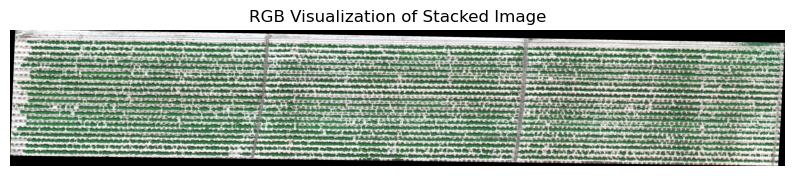

In [9]:
# INPUT STACKED IMAGE

crop_path = r"C:\Users\Say70\OneDrive - Mississippi State University\Desktop\UGA talk\6_10_2020\stack\6_10_2020_stack_AOI_crop.tif"


# FUNCTION: STRETCH IMAGE FOR DISPLAY

def percentile_stretch(img, pmin=2, pmax=98):
    """
    Stretch image band-wise for better visualization.
    img should be (rows, cols, bands)
    """
    img = img.astype(np.float32)
    out = np.zeros_like(img, dtype=np.float32)

    for i in range(img.shape[2]):
        band = img[:, :, i]
        low = np.percentile(band[np.isfinite(band)], pmin)
        high = np.percentile(band[np.isfinite(band)], pmax)

        if high > low:
            out[:, :, i] = np.clip((band - low) / (high - low), 0, 1)
        else:
            out[:, :, i] = 0

    return out


# READ STACKED IMAGE

with rasterio.open(crop_path) as src:
    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Band count:", src.count)

    # Read RGB bands
    # Your stack order is: B, G, R, RE, NIR
    # So RGB = bands 3, 2, 1
    r = src.read(3)
    g = src.read(2)
    b = src.read(1)

# Stack into RGB image
rgb = np.dstack((r, g, b))

# Stretch for display
rgb_display = percentile_stretch(rgb)

# VISUALIZATION OPTION 1: LIKE plotRGB(EX1, r=1, g=2, b=3)

plt.figure(figsize=(10, 10))
plt.imshow(rgb_display)
plt.title("RGB Visualization of Stacked Image")
plt.axis("off")
plt.show()